# Machine Learning - Assignment #2
### Neural Network Optimization
________________________________________________________________________________

In [198]:
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.utils import to_categorical

### Data Loading and Preprocessing
Load train and validation set, split the data into features and target and then One-Hot Encode the target column.

In [ ]:
train_df = pd.read_csv('small_train.csv')
val_df = pd.read_csv('small_validation.csv')

train_df.head(1)

,6,0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,...,0.90,0.91,0.92,0.93,0.94,0.95,0.96,0.97,0.98,0.99
0,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [200]:
# The column "6" of training set is the target. 
X_train = train_df.drop('6', axis=1).values
y_train = train_df['6'].values

# The column "5" of validation set is the target. 
X_val = val_df.drop('5', axis=1).values
y_val = val_df['5'].values

# (One-Hot Encode Target)
y_train_encoded = to_categorical(y_train, num_classes=10)
y_val_encoded = to_categorical(y_val, num_classes=10)

print(f"Training features shape: {X_train.shape}")
print(f"Training Targets shape: {y_train_encoded.shape}")
print(f"Validation features shape: {X_val.shape}")
print(f"Validation Targets shape: {y_val_encoded.shape}")


Training features shape: (499, 128)
Training Targets shape: (499, 10)
Validation features shape: (99, 128)
Validation Targets shape: (99, 10)


 Here we define a utility function for building and compiling the Neural Network. so we don't repeat this logic each step we need to create a new Neural Network.

In [203]:
def build_neural_network(hidden_layers, learning_rate = 0.001, kernel_initializer = 'random_normal', bias_initializer = 'random_normal'):
    model_hidden_layers = []
    for index, layer in enumerate(hidden_layers):
        model_hidden_layers.append(
            layers.Dense(
                layer['nodes_count'], 
                activation= layer['activation'], 
                kernel_initializer = kernel_initializer,
                bias_initializer = bias_initializer,
                name=f"hidden_layer_alpha_{index + 1}")
        )

    model = models.Sequential(
        model_hidden_layers + [
            layers.Dense(10, 
                    activation='softmax', 
                    kernel_initializer = kernel_initializer,
                    bias_initializer = bias_initializer,
                    name='output_layer_beta')
        ]
    )

    custom_optimizer = optimizers.Adam(learning_rate)

    model.compile(
        optimizer=custom_optimizer,
        loss='categorical_crossentropy',
        metrics=['categorical_crossentropy']
    )

    return model

def fit(model, epochs = 100):
    return model.fit(
        X_train, y_train_encoded,
        validation_data=(X_val, y_val_encoded),
        epochs=epochs,
        verbose=0 
    )

# 1. Hidden Units
Train a single hidden layer neural network using the hyperparameters mentioned in the table above, except for the number of hidden units which should vary among 5, 20, 50, 100, and 200. Run the optimization for 100 epochs each time.

In [204]:
hidden_unit_options = [5, 20, 50, 100, 200]
train_losses = []
val_losses = []

for units in hidden_unit_options:
    print(f"Training model with {units} hidden units...")

    model = build_neural_network([{ 'nodes_count' : units, 'activation': 'relu' }])
    
    history = fit(model)
    # get the average cross-entropy (loss) of the last epoch
    final_train_loss = history.history['loss'][-1]
    final_val_loss = history.history['val_loss'][-1]
    
    train_losses.append(final_train_loss)
    val_losses.append(final_val_loss)

    print(f"Done. Final Val Loss: {final_val_loss:.4f}")

Training model with 5 hidden units...
Done. Final Val Loss: 1.2141
Training model with 20 hidden units...
Done. Final Val Loss: 1.3972
Training model with 50 hidden units...
Done. Final Val Loss: 1.7044
Training model with 100 hidden units...
Done. Final Val Loss: 1.8493
Training model with 200 hidden units...
Done. Final Val Loss: 1.9447


### Plotting Loss vs. Hidden Units
<b>1.1</b> Plot the average training cross-entropy (sum of the cross-entropy terms over the training dataset divided by the total number of training examples) of the final epoch on the y-axis vs number of hidden units on the x-axis. In the same figure, plot the average validation cross-entropy. The x-axis should be the number of hidden units, the y-axis should be average cross-entropy loss, and there should be one curve for validation loss and one curve for train loss.

<b>Note:</b> We are using epochs=100 as requested. And we use the average loss of the final epoch(#100) only. 

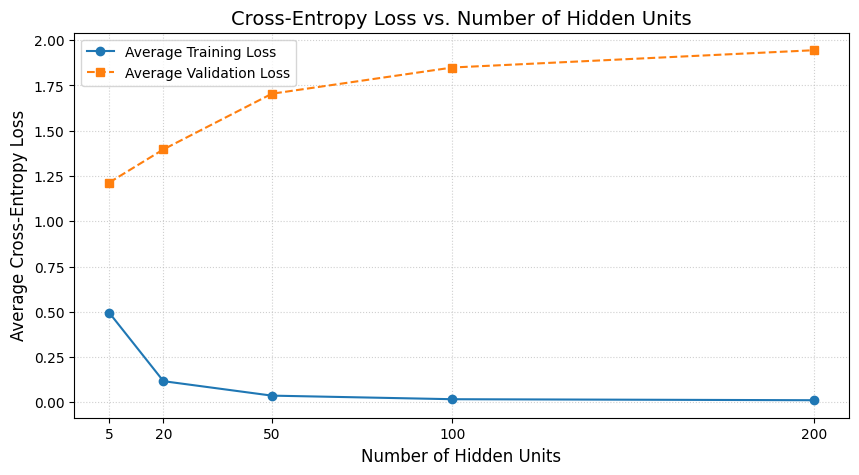

In [205]:
plt.figure(figsize=(10, 5))

plt.plot(hidden_unit_options, train_losses, marker='o', linestyle='-', label='Average Training Loss')
plt.plot(hidden_unit_options, val_losses, marker='s', linestyle='--', label='Average Validation Loss')

plt.title('Cross-Entropy Loss vs. Number of Hidden Units', fontsize=14)
plt.xlabel('Number of Hidden Units', fontsize=12)
plt.ylabel('Average Cross-Entropy Loss', fontsize=12)
plt.xticks(hidden_unit_options)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()

plt.show()


<b>1.2</b> Examine and comment on the plots of training and validation cross-entropy. What problem arises with too few hidden units, and why does it happen?<br><br>
When hidden units are insufficient (5), the model was experiencing underfitting and wasn't able to capture complex relationships between features. This results in a high training error (high bias). However, as the number of hidden units increases, the generalization gap widens: training loss continues to decrease while validation loss rises, indicating that the higher model capacity is leading to overfitting.
<br><br>Interestingly, the best validation error in this experiment was achieved with only 5 units. This is likely a result of setting the training duration to a fixed 100 epochs, which allows more complex models to over-optimize and memorize noise by the end of the run. Had early stopping been utilized as a regularization mechanism, the optimal generalization point would likely shift to a more moderate capacity, such as 20 or 50 hidden units.
___________________________________________________________



# 2. Weight Initialization
<b>2.1</b> Initialize α and β to zero and print them out after the first few updates.

In [163]:
model_zero = build_neural_network(
    [{ 'nodes_count' : 50, 'activation': 'relu' }],
    kernel_initializer = 'zeros',
    bias_initializer = 'zeros'
)

history = fit(model_zero, 2)

In [165]:
print("\n----- Weights AFTER first updates (Sample of Alpha) -----")
alpha_after = model_zero.get_layer('hidden_layer_alpha_1').get_weights()
print('alpha - weights:', alpha_after[0][0])
print('alpha - biases:', alpha_after[1])

print("\n----- Weights AFTER first updates (Sample of Beta) -----")
beta_after = model_zero.get_layer('output_layer_beta').get_weights()
print('beta - weights:', beta_after[0][0])
print('beta - biases:', beta_after[1])


----- Weights AFTER first updates (Sample of Alpha) -----
alpha - weights: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0.]
alpha - biases: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0.]

----- Weights AFTER first updates (Sample of Beta) -----
beta - weights: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
beta - biases: [ 0.00176724 -0.00049374 -0.00234685 -0.0015203  -0.00165392  0.00172684
  0.00091906 -0.00506368 -0.00161764  0.00180769]


<b>2.2</b> Compare the values across rows and columns in α and β. Describe the observed behavior and explain why this may happen

Since we initialized all weights and biases to zero, the input to our hidden layer activation is *Zeros*:
$$a = \alpha \cdot x + \alpha_b = 0 \cdot x + 0 = 0$$
Because we are using the ReLU activation function, the output of the hidden layer becomes *Zeros* as well:
$$\text{ReLU}(a) = \max(0, 0) = 0$$
This means the hidden layer is passing a vector of pure zeros to the output layer.

In back-propagation, when we tries to update the weights, it calculates the gradient. 
However, the gradient that related to a specific weight is depend on the value of the input that is tied to it, for example in the output layer the gradient for $\beta$ is defined as:
$$(\hat{y} - y) \cdot h$$
Where h is the hidden layer output and it was 0, so the entire gradient for $\beta$ becomes 0. If the gradient is zero, the weight update ($\beta = \beta - \eta \cdot \text{grad}$) does nothing. The weights stay at zero. 
The same is applied For the hidden layer weights ($\alpha$).

Why did the Output Biases ($\beta_b$) move?

The output biases are *NOT* Zeros because their gradients doesn't depend on the input, it is simply:
$$(\hat{y} - y)$$
This gradient does not depend on the output layer inputs (the hidden layer outputs). It only cares about the difference between our prediction ($\hat{y}$) and the actual label ($y$).
_____________________________________


# 3. Adding A Second (Sigmoid) Hidden Layer

Now, try adding another hidden layer to your neural network. The hyperparameters for the model should be the same as the table above, except for learning rate. The 2 hidden layers should both have a dimension of 50, and your learning rate should be 0.003. Run the optimization for 100 epochs. Remember that adding another hidden layer means you should add both a linear layer and a sigmoid layer in your code.
<br/><br/><b>3.1</b> We want to compare the performance of this model with our 1 hidden layer model. So, create a plot with the following 4 lines. Plot the average training and validation cross-entropy loss for a 1 hidden layer model, using the same learning rate of 0.003 and a hidden dimension of 50. Additionally, plot the average training and validation cross-entropy loss for the 2 hidden layer model on the same figure. The x-axis should be epoch number, the y-axis should be average cross-entropy loss, and there should be
four total curves: training loss and validation loss for the 1 hidden layer model, and training loss and validation loss for the 2 hidden layer model.

In [ ]:
train_losses = []
val_losses = []

model_1_layer = build_neural_network([{ 'nodes_count' : 50, 'activation': 'relu' }], learning_rate=0.003)
model_2_layer = build_neural_network([{ 'nodes_count' : 50, 'activation': 'relu' },{ 'nodes_count' : 50, 'activation': 'sigmoid' }], learning_rate=0.003)

history_1 = fit(model_1_layer)
history_2 = fit(model_2_layer)

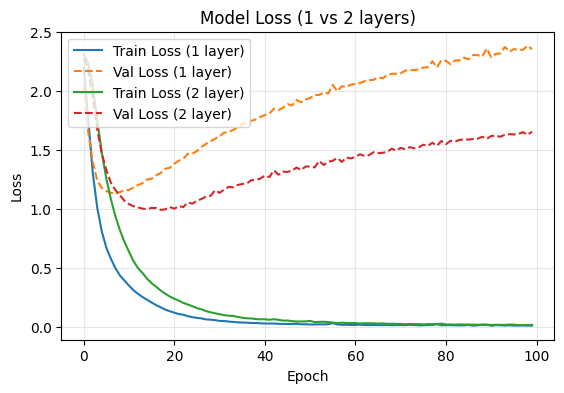

In [207]:
plt.figure(figsize=(14, 4))

plt.subplot(1, 2, 2)
plt.plot(history_1.history['loss'], label='Train Loss (1 layer)')
plt.plot(history_1.history['val_loss'], label='Val Loss (1 layer)', linestyle='--')
plt.plot(history_2.history['loss'], label='Train Loss (2 layer)')
plt.plot(history_2.history['val_loss'], label='Val Loss (2 layer)', linestyle='--')
plt.title('Model Loss (1 vs 2 layers)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

<b>3.2</b> Examine and comment on the difference in performance between the two model. What happens when you add an additional hidden layer? Why do you think this is happening? Frame your answer in terms of model complexity and overfitting/underfitting.<br><br>

Both models exhibit clear overfitting, but the 2-layer model outperforms the 1-layer model on validation data. While both models achieve near-zero training loss, the 2-layer model (red/green) generalizes better than the 1-layer model (blue/orange). The 1-layer model's validation loss bottoms out very early (around epoch 5) and then rises again, reaching a loss of over 2.0.
The 2-layer model's validation loss reaches a lower minimum and climbs much more slowly, ending around 1.7.

Adding the second hidden layer (with Sigmoid activation) slowed down the convergence of the training loss (the green line stays above the blue line for the first 60 epochs). However, it provided a lower validation error and a more stable learning curve.

Theoretically, adding a second layer increases the model's complexity (more weights and parameters). Usually, higher complexity on a small dataset leads to worse overfitting. However, in this specific case, it looks that the Sigmoid layer acting as a form of implicit regularization with its ability to squashes values between $0$ and $1$, which at ends leads to a better generalization error. 

# 4. Activation Function
Train two single hidden layer neural networks, one using a ReLU activation function and another using a sigmoid activation function on the hidden layer. The single hidden layer in the two models should both have a dimension of 50, and your learning rate should be 0.003. Run the optimization for 100 epochs.<br><br>
<b>4.1</b> Compare the convergence of the two models by plotting the following 4 lines on the same graph. Plot the average training and validation cross-entropy loss for the model with a ReLU activation and the model with a sigmoid activation.

In [ ]:
train_losses = []
val_losses = []

model_relu = build_neural_network([{ 'nodes_count' : 50, 'activation': 'relu' }], learning_rate=0.003)
model_sigmoid = build_neural_network([{ 'nodes_count' : 50, 'activation': 'sigmoid' }], learning_rate=0.003)

history_1 = fit(model_relu)
history_2 = fit(model_sigmoid)

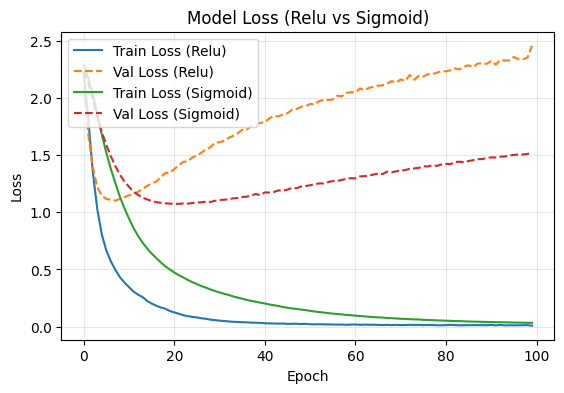

In [209]:
plt.figure(figsize=(14, 4))

plt.subplot(1, 2, 2)
plt.plot(history_1.history['loss'], label='Train Loss (Relu)')
plt.plot(history_1.history['val_loss'], label='Val Loss (Relu)', linestyle='--')
plt.plot(history_2.history['loss'], label='Train Loss (Sigmoid)')
plt.plot(history_2.history['val_loss'], label='Val Loss (Sigmoid)', linestyle='--')
plt.title('Model Loss (Relu vs Sigmoid)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

<b>4.2</b> Examine and comment on the difference in convergence between the two models. Which activation function allows the model to converge faster and why?


The ReLU activation function (blue/orange lines) allows the model to converge faster than the Sigmoid activation function (green/red lines).
The ReLU training loss (solid blue) drops sharply and reaches near-zero levels by roughly epoch 40, whereas the Sigmoid training loss (solid green) takes until epoch 90 to reach a similar level of minimization.

The difference in convergence speed is primarily due to the types of the gradients for each function:
* Vanishing Gradient in Sigmoid: The Sigmoid function squashes any input into a narrow range between 0 and 1. As a result, its derivative (gradient) is always small. During back-propagation, these small gradients minimize the weight updates to become tiny, which slows down the learning process significantly.

* Constant Gradient in ReLU: ReLU follows a much simpler logic, For any positive input, the gradient is a constant 1. This property on the positive side allows the gradient to flow through the network without being vanished or squashed. This leads to much larger weight updates.

# 5. Adding a Hidden Layer and Activation Function:
Now, try adding another hidden layer to both of the above neural networks. The hyperparameters for the models should be the same as above, and one neutral network should use ReLU and another should use sigmoid as their activation functions. Remember that adding another hidden layer means you should add both a linear layer and a ReLU/sigmoid layer in your code.
<br><br>
<b>5.1</b> Plot the average training and validation cross-entropy loss for the model with a ReLU activation and the model with a sigmoid activation.

In [ ]:
train_losses = []
val_losses = []

model_relu_2_layers = build_neural_network([{ 'nodes_count' : 50, 'activation': 'relu' }, { 'nodes_count' : 50, 'activation': 'relu' }], learning_rate=0.003)
model_sigmoid_2_layers = build_neural_network([{ 'nodes_count' : 50, 'activation': 'sigmoid' }, { 'nodes_count' : 50, 'activation': 'sigmoid' }], learning_rate=0.003)

history_1 = fit(model_relu_2_layers)
history_2 = fit(model_sigmoid_2_layers)


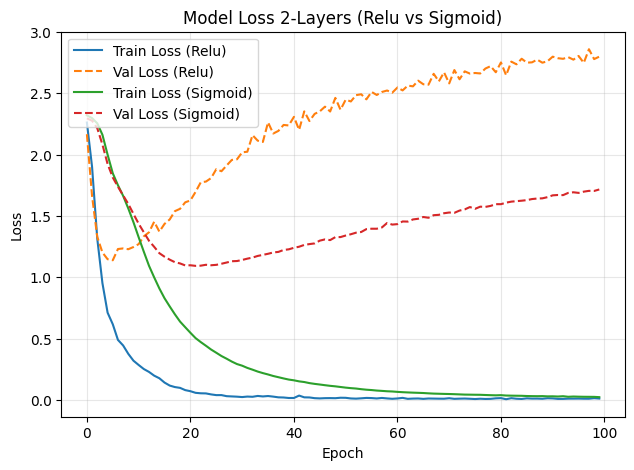

In [ ]:
plt.figure(figsize=(16, 5))

plt.subplot(1, 2, 2)
plt.plot(history_1.history['loss'], label='Train Loss (Relu)')
plt.plot(history_1.history['val_loss'], label='Val Loss (Relu)', linestyle='--')
plt.plot(history_2.history['loss'], label='Train Loss (Sigmoid)')
plt.plot(history_2.history['val_loss'], label='Val Loss (Sigmoid)', linestyle='--')
plt.title('Model Loss 2-Layers (Relu vs Sigmoid)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

<b>5.2</b> Examine and comment on the difference in convergence between the two models (the 1-hidden-layer model vs the 2-hidden-layer model) across both activation functions. Did this effect become more or less or equally as severe as the number of hidden layers increases?

The gap in convergence speed between the two functions is more clear in the 2-layer model. This is because gradients are multiplied layer by layer during backpropagation. In Sigmoid Network, Adding a second layer means the gradient signal reaching the first set of weights is multiplied by these small fractions twice, making the Vanishing Gradient problem worse.

It's also worth pointing out that while the sigmoid network training was slower, its "squashing" nature ($0$ to $1$) acted as a regularization mechanism, preventing the added complexity of the second layer from causing the same level of overfitting seen in the ReLU model.